Importing Libraries

In [0]:
from pyspark.sql.functions import col, mean, when, split, isnan, round as spark_round
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator 
import pandas as pd
import matplotlib.pyplot as plt 
# Configures the Databricks notebook environment to render the bar chart inline
%matplotlib inline

STORAGE SYSTEM ATTACHMENT

In [0]:
storage_account_name = "ddosarchstgabc"
container_name = "ingested-data"  
storage_account_key = "W+Ph370us+MLe4lLFRw7LLUOaAkpI0Qr8N09Q/rlpMWqhHHCUvf9LZ0Qz/SYmYr2MciR/761xPNh+AStAyPkHw=="

# Establish secure ADLS Gen2 direct session keys
spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

file_path = f"abfss://{container_name}@{storage_account_name}.dfs.core.windows.net/Syn.csv"

###DATA PRE-PROCESSING

Load Data and Inspect

In [0]:
raw_text_df = spark.read.text(file_path)
raw_header_str = raw_text_df.limit(1).first()["value"]

# To clean spaces and dots from headers immediately by using native Python
original_headers = [c.strip().replace(".", "_").replace(" ", "_") for c in raw_header_str.split(",")]

# Automated duplicate column handling (whcich Resolves "Fwd_Header_Length" collisions)
seen = {}
clean_headers = []
for header in original_headers:
    if header in seen:
        seen[header] += 1
        clean_headers.append(f"{header}_{seen[header]}")
    else:
        seen[header] = 0
        clean_headers.append(header)

# Project unparsed strings into individual structured dataframe fields
data_rows_df = raw_text_df.filter(col("value") != raw_header_str)
split_df = data_rows_df.withColumn("parsed_array", split(col("value"), ","))

for i, header_name in enumerate(clean_headers):
    split_df = split_df.withColumn(header_name, col("parsed_array").getItem(i))

# Create our base processing DataFrame
df_raw = split_df.drop("value", "parsed_array")

print(f"Total rows processed: {df_raw.count()}")
print(f"Total columns structured: {len(df_raw.columns)}")
display(df_raw.limit(5))  

Total rows processed: 4320541
Total columns structured: 88


Unnamed:_0,Flow_ID,Source_IP,Source_Port,Destination_IP,Destination_Port,Protocol,Timestamp,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes/s,Flow_Packets/s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_PSH_Flags,Bwd_PSH_Flags,Fwd_URG_Flags,Bwd_URG_Flags,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets/s,Bwd_Packets/s,Min_Packet_Length,Max_Packet_Length,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,FIN_Flag_Count,SYN_Flag_Count,RST_Flag_Count,PSH_Flag_Count,ACK_Flag_Count,URG_Flag_Count,CWE_Flag_Count,ECE_Flag_Count,Down/Up_Ratio,Average_Packet_Size,Avg_Fwd_Segment_Size,Avg_Bwd_Segment_Size,Fwd_Header_Length_1,Fwd_Avg_Bytes/Bulk,Fwd_Avg_Packets/Bulk,Fwd_Avg_Bulk_Rate,Bwd_Avg_Bytes/Bulk,Bwd_Avg_Packets/Bulk,Bwd_Avg_Bulk_Rate,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,SimillarHTTP,Inbound,Label
445444,172.16.0.5-192.168.50.4-9429-9429-6,172.16.0.5,9429,192.168.50.4,9429,6,2018-11-03 11:36:28.607338,36063894,7,2,42.0,12.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.4973424666787232,0.2495570777797872,4507986.75,7062714.372789215,18628035.0,1.0,36063894.0,6010649.0,7680922.56495114,18628035.0,1.0,2.0,2.0,0.0,2.0,2.0,0,0,0,0,140,40,0.19409994938427894,0.05545712839550826,6.0,6.0,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0.0,6.666666666666668,6.0,6.0,140,0,0,0,0,0,0,7,42,2,12,5840,0,6,20,18.0,29.44486372867091,52.0,1.0,12021279.666666664,6253623.030351313,18628035.0,6193840.0,0,1,Syn
113842,172.16.0.5-192.168.50.4-60224-60224-6,172.16.0.5,60224,192.168.50.4,60224,6,2018-11-03 11:36:28.607339,44851366,8,4,48.0,24.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.6053022777500243,0.26755037962500405,4077396.9090909087,9056966.723853623,28934293.0,1.0,44851314.0,6407330.571428573,10922353.65918872,28934293.0,1.0,3525902.0,1175300.6666666665,2035678.7367854328,3525900.0,1.0,0,0,0,0,160,80,0.1783669197500027,0.08918345987500136,6.0,6.0,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0.0,6.5,6.0,6.0,160,0,0,0,0,0,0,8,48,4,24,5840,0,7,20,1.0,0.0,1.0,1.0,20662676.5,11697832.237049073,28934293.0,12391060.0,0,1,Syn
176377,172.16.0.5-192.168.50.4-33827-11746-6,192.168.50.4,11746,172.16.0.5,33827,6,2018-11-03 11:36:28.607388,1,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,1.2E7,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2000000.0,0.0,6.0,6.0,6.0,0.0,0.0,0,1,0,0,0,1,0,0,0.0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,0,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,Syn
24777,172.16.0.5-192.168.50.4-33828-1431-6,172.16.0.5,33828,192.168.50.4,1431,6,2018-11-03 11:36:28.607391,0,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,Infinity,Infinity,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,0.0,0.0,6.0,6.0,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0.0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,5840,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,Syn
85100,172.16.0.5-192.168.50.4-5311-5311-6,172.16.0.5,5311,192.168.50.4,5311,6,2018-11-03 11:36:28.607442,35731470,8,2,48.0,12.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.6791920399580538,0.27986533999300894,3970163.333333334,6026603.539329906,13693985.0,0.0,35731470.0,5104495.714285715,6455349.183124325,13693985.0,0.0,1.0,1.0,0.0,1.0,1.0,0,0,0,0,160,40,0.2238922719944072,0.05597306799860178,6.0,6.0,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0.0,6.6,6.0,6.0,160,0,0,0,0,0,0,8,48,2,12,5840,0,7,20,24.5,33.23401871576773,48.0,1.0,11910473.333333336,1849493.0018608703,13693985.0,10001398.0,0,1,Syn


Handle Infinite Values and Missing Data

In [0]:
# Modify the column names to remove spaces and dots
exclude_names = ["Unnamed:_0", "Label", "target_label", "Flow_ID", "Timestamp", "Source_IP", "Destination_IP", "SimillarHTTP"]
numeric_cols = [c for c in df_raw.columns if c not in exclude_names]

df_typed = df_raw

# Enhanced, crash-proof numeric conversion loop with comprehensive check bounds
for c in numeric_cols:
    df_typed = df_typed.withColumn(c, col(c).try_cast(DoubleType()))
    df_typed = df_typed.withColumn(
        c,
        when((col(c).isNull()) | (col(c) == float('inf')) | (col(c) == float('-inf')) | (isnan(col(c))), None)
        .otherwise(col(c))
    )

# Compute all mathematical means simultaneously in one pass across the cluster
mean_expressions = [mean(col(c)).alias(c) for c in numeric_cols]
means_row_data = df_typed.select(mean_expressions).first()
means_dict = means_row_data.asDict()

fill_map = {c: means_dict[c] for c in numeric_cols if means_dict[c] is not None}
cols_to_drop = [c for c in numeric_cols if means_dict[c] is None]

# Impute null spaces with their corresponding mean figures
df_typed = df_typed.fillna(fill_map)
if cols_to_drop:
    df_typed = df_typed.drop(*cols_to_drop)

print(f"Numeric Attributes Cleaned and Imputed: {len(fill_map)}")
if cols_to_drop:
    print(f"Dropped completely null features: {cols_to_drop}")

Numeric Attributes Cleaned and Imputed: 81


Encode Target Label

In [0]:
df_clean = df_typed.withColumn(
    "target_label", 
    when(col("Label") == "BENIGN", 0).otherwise(1).cast(IntegerType())
).drop("Label")

# Clear lingering null instances prior to vector array conversion steps
feature_cols = [c for c in df_clean.columns if c not in exclude_names]
df_clean = df_clean.dropna(subset=feature_cols + ["target_label"])

df_clean.groupBy("target_label").count().show()  

+------------+-------+
|target_label|  count|
+------------+-------+
|           1|4284751|
|           0|  35790|
+------------+-------+



Assemble Feature Vector

In [0]:
# Assembly of feature vectors
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
df_assembled = assembler.transform(df_clean)

print(f"Feature vector compiled successfully using {len(feature_cols)} metrics.")
display(df_assembled.select("features", "target_label").limit(5))  

Feature vector compiled successfully using 81 metrics.


features,target_label
"Map(vectorType -> dense, length -> 81, values -> List(9429.0, 9429.0, 6.0, 3.6063894E7, 7.0, 2.0, 42.0, 12.0, 6.0, 6.0, 6.0, 0.0, 6.0, 6.0, 6.0, 0.0, 1.4973424666787232, 0.2495570777797872, 4507986.75, 7062714.372789215, 1.8628035E7, 1.0, 3.6063894E7, 6010649.0, 7680922.56495114, 1.8628035E7, 1.0, 2.0, 2.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 140.0, 40.0, 0.19409994938427894, 0.05545712839550826, 6.0, 6.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 6.666666666666668, 6.0, 6.0, 140.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 42.0, 2.0, 12.0, 5840.0, 0.0, 6.0, 20.0, 18.0, 29.44486372867091, 52.0, 1.0, 1.2021279666666664E7, 6253623.030351313, 1.8628035E7, 6193840.0, 1.0))",1
"Map(vectorType -> dense, length -> 81, values -> List(60224.0, 60224.0, 6.0, 4.4851366E7, 8.0, 4.0, 48.0, 24.0, 6.0, 6.0, 6.0, 0.0, 6.0, 6.0, 6.0, 0.0, 1.6053022777500243, 0.26755037962500405, 4077396.9090909087, 9056966.723853623, 2.8934293E7, 1.0, 4.4851314E7, 6407330.571428573, 1.092235365918872E7, 2.8934293E7, 1.0, 3525902.0, 1175300.6666666665, 2035678.7367854328, 3525900.0, 1.0, 0.0, 0.0, 0.0, 0.0, 160.0, 80.0, 0.1783669197500027, 0.08918345987500136, 6.0, 6.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 6.5, 6.0, 6.0, 160.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0, 48.0, 4.0, 24.0, 5840.0, 0.0, 7.0, 20.0, 1.0, 0.0, 1.0, 1.0, 2.06626765E7, 1.1697832237049073E7, 2.8934293E7, 1.239106E7, 1.0))",1
"Map(vectorType -> sparse, length -> 81, indices -> List(0, 1, 2, 3, 4, 6, 8, 9, 10, 16, 17, 18, 20, 21, 22, 23, 25, 26, 36, 38, 40, 41, 42, 46, 50, 54, 55, 57, 64, 65, 69, 70, 71), values -> List(11746.0, 33827.0, 6.0, 1.0, 2.0, 12.0, 6.0, 6.0, 6.0, 1.2E7, 2000000.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 40.0, 2000000.0, 6.0, 6.0, 6.0, 1.0, 1.0, 9.0, 6.0, 40.0, 2.0, 12.0, -1.0, 1.0, 20.0))",1
"Map(vectorType -> sparse, length -> 81, indices -> List(0, 1, 2, 4, 6, 8, 9, 10, 16, 17, 36, 40, 41, 42, 49, 54, 55, 57, 64, 65, 68, 69, 70, 71, 80), values -> List(33828.0, 1431.0, 6.0, 2.0, 12.0, 6.0, 6.0, 6.0, 5590467.984704852, 847524.8727459873, 40.0, 6.0, 6.0, 6.0, 1.0, 9.0, 6.0, 40.0, 2.0, 12.0, 5840.0, -1.0, 1.0, 20.0, 1.0))",1
"Map(vectorType -> dense, length -> 81, values -> List(5311.0, 5311.0, 6.0, 3.573147E7, 8.0, 2.0, 48.0, 12.0, 6.0, 6.0, 6.0, 0.0, 6.0, 6.0, 6.0, 0.0, 1.6791920399580538, 0.27986533999300894, 3970163.333333334, 6026603.539329906, 1.3693985E7, 0.0, 3.573147E7, 5104495.714285715, 6455349.183124325, 1.3693985E7, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 160.0, 40.0, 0.2238922719944072, 0.05597306799860178, 6.0, 6.0, 6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 6.6, 6.0, 6.0, 160.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0, 48.0, 2.0, 12.0, 5840.0, 0.0, 7.0, 20.0, 24.5, 33.23401871576773, 48.0, 1.0, 1.1910473333333336E7, 1849493.0018608703, 1.3693985E7, 1.0001398E7, 1.0))",1


###DATA ANALYSIS & INSIGHTS

Train / Validation / Test Split

In [0]:
print("\n[METHODOLOGY] Creating train / validation / test splits...")
train, temp = df_assembled.randomSplit([0.7, 0.3], seed=42)
val, test = temp.randomSplit([0.5, 0.5], seed=42)

print(f"Training records: {train.count()}")
print(f"Validation records: {val.count()}")
print(f"Test records: {test.count()}")


[METHODOLOGY] Creating train / validation / test splits...
Training records: 3024920
Validation records: 648917
Test records: 646704


In [0]:
# --- Train Random Forest with informed hyperparameters  ---
# Using parameters known to work well for network intrusion detection
# to avoid expensive grid search while still showing critical thinking.
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="target_label",
    numTrees=100,          # standard ensemble size
    maxDepth=15,           # sufficient depth for complex patterns
    minInstancesPerNode=2, # avoid overfitting
    subsamplingRate=0.8,   # stochastic sampling for diversity
    seed=42
)

print("\n Training Random Forest model...")
model = rf.fit(train)

# --- Evaluate on Validation Set (model selection step) ---
val_pred = model.transform(val)
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="target_label", metricName="f1")
val_f1 = evaluator_f1.evaluate(val_pred)
print(f"Validation F1 Score: {val_f1:.4f}")


 Training Random Forest model...
Validation F1 Score: 1.0000


In [0]:
# --- Final Evaluation on Test Set (unseen data) ---
test_pred = model.transform(test)
accuracy = MulticlassClassificationEvaluator(labelCol="target_label", metricName="accuracy").evaluate(test_pred)
f1 = evaluator_f1.evaluate(test_pred)

print(f"\n--- FINAL MODEL PERFORMANCE ON TEST SET ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}\n")

print("--- CONFUSION MATRIX DATA ---")
test_pred.groupBy("target_label", "prediction").count().show()


--- FINAL MODEL PERFORMANCE ON TEST SET ---
Accuracy: 1.0000
F1 Score: 1.0000

--- CONFUSION MATRIX DATA ---
+------------+----------+------+
|target_label|prediction| count|
+------------+----------+------+
|           0|       0.0|  5264|
|           1|       1.0|641430|
|           1|       0.0|     4|
|           0|       1.0|     6|
+------------+----------+------+



Feature Importance

In [0]:
# --- Feature Importance  ---
importance_array = model.featureImportances.toArray()
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_array
}).sort_values("importance", ascending=False)

print("\n--- TOP 10 PREDICTIVE FEATURES ---")
print(importance_df.head(10))


--- TOP 10 PREDICTIVE FEATURES ---
                   feature  importance
49          ACK_Flag_Count    0.105995
80                 Inbound    0.103109
43       Packet_Length_Std    0.089102
44  Packet_Length_Variance    0.074110
42      Packet_Length_Mean    0.053881
68  Init_Win_bytes_forward    0.047119
50          URG_Flag_Count    0.043198
10  Fwd_Packet_Length_Mean    0.040270
41       Max_Packet_Length    0.035206
55    Avg_Fwd_Segment_Size    0.028324


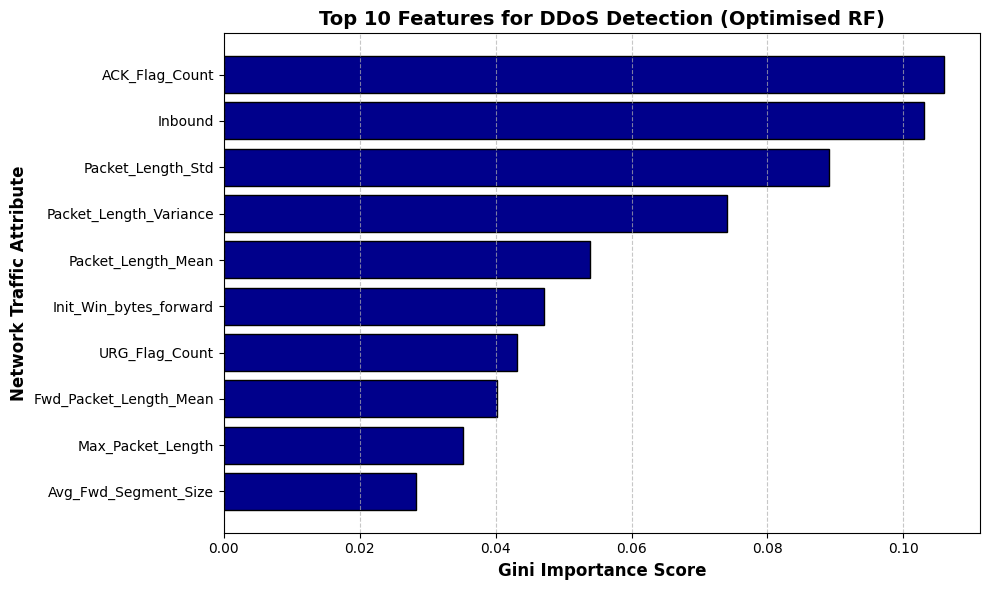

In [0]:
# --- Visualisation ---
top_10 = importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10["feature"][::-1], top_10["importance"][::-1], color='darkblue', edgecolor='black')
plt.xlabel("Gini Importance Score", fontsize=12, fontweight='bold')
plt.ylabel("Network Traffic Attribute", fontsize=12, fontweight='bold')
plt.title("Top 10 Features for DDoS Detection (Optimised RF)", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [0]:
# --- Analytical SQL Query  ---
df_clean.createOrReplaceTempView("flows")
print("\n--- ANALYTICAL COMPARISON: ATTACK VS BENIGN TRAFFIC ---")
spark.sql("""
    SELECT 
        CASE WHEN target_label = 1 THEN 'Attack (SYN Flood)' ELSE 'Benign Traffic' END AS traffic_type,
        ROUND(AVG(Fwd_Packet_Length_Mean), 4) AS avg_fwd_pkt_len,
        ROUND(AVG(Flow_Duration), 4) AS avg_duration_ms
    FROM flows
    GROUP BY target_label
""").show()


--- ANALYTICAL COMPARISON: ATTACK VS BENIGN TRAFFIC ---
+------------------+---------------+---------------+
|      traffic_type|avg_fwd_pkt_len|avg_duration_ms|
+------------------+---------------+---------------+
|Attack (SYN Flood)|         6.5772|   5299681.9283|
|    Benign Traffic|        42.0221|1.44680844827E7|
+------------------+---------------+---------------+



In [0]:
print("\n--- High Intensity Flow Analysis ---")
spark.sql("""
    SELECT 
        CASE WHEN target_label = 1 THEN 'Attack' ELSE 'Benign' END AS traffic_type,
        COUNT(*) AS total_flows,
        SUM(CASE WHEN `Flow_Packets/s` > 1000 THEN 1 ELSE 0 END) AS high_intensity_flows,
        ROUND(SUM(CASE WHEN `Flow_Packets/s` > 1000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_high_intensity
    FROM flows
    GROUP BY target_label
""").show()


--- High Intensity Flow Analysis ---
+------------+-----------+--------------------+------------------+
|traffic_type|total_flows|high_intensity_flows|pct_high_intensity|
+------------+-----------+--------------------+------------------+
|      Attack|    4284751|             3781878|             88.26|
|      Benign|      35790|               13265|             37.06|
+------------+-----------+--------------------+------------------+



In [0]:
print("\n--- Top 5 Malicious Source IPs ---")
spark.sql("""
    SELECT 
        Source_IP,
        COUNT(*) AS total_flows,
        SUM(target_label) AS attack_flows,
        ROUND(SUM(target_label) * 100.0 / COUNT(*), 2) AS attack_percentage
    FROM flows
    GROUP BY Source_IP
    HAVING COUNT(*) > 10
    ORDER BY attack_percentage DESC
    LIMIT 5
""").show()


--- Top 5 Malicious Source IPs ---
+--------------+-----------+------------+-----------------+
|     Source_IP|total_flows|attack_flows|attack_percentage|
+--------------+-----------+------------+-----------------+
|    172.16.0.5|    4281316|     4281316|           100.00|
|  192.168.50.4|       3713|        3435|            92.51|
|  192.168.50.6|      12225|           0|             0.00|
|192.168.50.254|        212|           0|             0.00|
|  192.168.50.8|       8747|           0|             0.00|
+--------------+-----------+------------+-----------------+



In [0]:
print("\n--- Packet Length Anomaly Detection ---")
spark.sql("""
    SELECT 
        CASE WHEN target_label = 1 THEN 'Attack (SYN Flood)' ELSE 'Benign Traffic' END AS traffic_type,
        ROUND(AVG(Packet_Length_Mean), 2) AS avg_packet_length,
        ROUND(MIN(Packet_Length_Mean), 2) AS min_packet_length,
        ROUND(MAX(Packet_Length_Mean), 2) AS max_packet_length,
        ROUND(STDDEV(Packet_Length_Mean), 2) AS stddev_packet_length
    FROM flows
    GROUP BY target_label
""").show()


--- Packet Length Anomaly Detection ---
+------------------+-----------------+-----------------+-----------------+--------------------+
|      traffic_type|avg_packet_length|min_packet_length|max_packet_length|stddev_packet_length|
+------------------+-----------------+-----------------+-----------------+--------------------+
|Attack (SYN Flood)|             6.58|              0.0|           1017.0|               16.45|
|    Benign Traffic|            77.88|              0.0|          1721.14|              149.08|
+------------------+-----------------+-----------------+-----------------+--------------------+



In [0]:
print("\n--- SYN/ACK Ratio Attack Signature ---")
spark.sql("""
    SELECT 
        CASE WHEN target_label = 1 THEN 'Attack' ELSE 'Benign' END AS traffic_type,
        ROUND(AVG(SYN_Flag_Count), 2) AS avg_syn_flags,
        ROUND(AVG(ACK_Flag_Count), 2) AS avg_ack_flags,
        ROUND(AVG(SYN_Flag_Count) / NULLIF(AVG(ACK_Flag_Count), 0), 2) AS syn_to_ack_ratio,
        COUNT(*) AS total_flows
    FROM flows
    GROUP BY target_label
""").show()


--- SYN/ACK Ratio Attack Signature ---
+------------+-------------+-------------+----------------+-----------+
|traffic_type|avg_syn_flags|avg_ack_flags|syn_to_ack_ratio|total_flows|
+------------+-------------+-------------+----------------+-----------+
|      Attack|          0.0|          1.0|             0.0|    4284751|
|      Benign|          0.0|         0.21|            0.02|      35790|
+------------+-------------+-------------+----------------+-----------+

